In [10]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset  # 用于构建数据集和批量加载训练数据
from sklearn.model_selection import train_test_split

### 数据生成

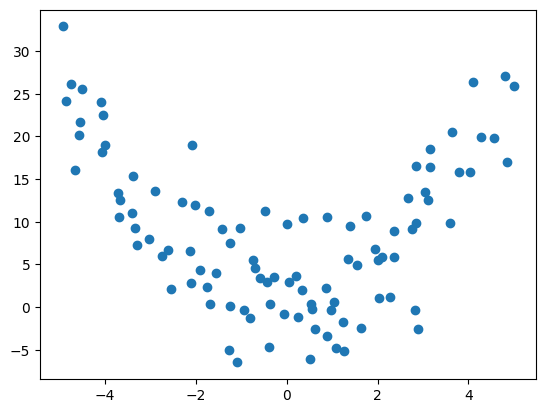

In [11]:
np.random.seed(32)

# 生成满足 y = x^2 + 1 基本关系的数据
num_samples = 100  # 样本数量
X = np.random.uniform(-5, 5, (num_samples, 1))  # 在 [-5, 5] 范围内均匀生成 100 个 X 值
Y = X ** 2 + 1 + 5 * np.random.normal(0, 1, (num_samples, 1))  # 生成目标值 y = x^2 + 1，并加入正态分布随机噪声

# 将 NumPy 数组转换为 PyTorch Tensor，并转换为 float32
X = torch.from_numpy(X).float()
Y = torch.from_numpy(Y).float()

plt.scatter(X, Y)
plt.show()

### 数据划分

In [12]:
train_X, test_X, train_Y, test_Y = train_test_split(X, Y, test_size=0.3, random_state=0)

# 将数据封装为 DataLoader
# DataLoader：用于将数据集按批次（Batch）加载，并支持随机打乱等操作，方便神经网络训练。
# TensorDataset(train_X, train_Y) 的作用是：把特征 X 和对应标签 Y 按样本一一配对，封装成一个 PyTorch 数据集。
train_dataloader = DataLoader(TensorDataset(train_X, train_Y), batch_size=32, shuffle=True)
test_dataloader = DataLoader(TensorDataset(test_X, test_Y), batch_size=32, shuffle=False)

### 模型定义

In [13]:
# 定义线性回归模型：只有一个线性层，无法很好拟合非线性数据，容易欠拟合
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)  # 输入 1 个特征，输出 1 个预测值
    def forward(self, x):  # 前向传播：直接进行线性变换
        return self.linear(x)

# 定义简单的多层感知机（MLP），用于学习非线性关系
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(1, 8)  # 隐藏层：1 个输入特征 → 8 个神经元
        self.output = nn.Linear(8, 1)  # 输出层：8 个隐藏层特征 → 1 个预测值
    def forward(self, x):
        x = torch.relu(self.hidden(x))  # 隐藏层后使用 ReLU 激活函数，引入非线性
        return self.output(x)  # 输出最终预测结果


# 定义更复杂的 MLP：参数较多，在小数据集上更容易过拟合
class MLPOverfitting(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(1, 256)    # 第一隐藏层：1 → 256
        self.hidden2 = nn.Linear(256, 256)  # 第二隐藏层：256 → 256
        self.output = nn.Linear(256, 1)     # 输出层：256 → 1
    def forward(self, x):
        x = torch.relu(self.hidden1(x))  # 第一隐藏层 + ReLU
        x = torch.relu(self.hidden2(x))  # 第二隐藏层 + ReLU
        return self.output(x)            # 输出预测值

### 误差记录函数

In [14]:
def plot_errors(models, num_epochs, train_dataloader, test_dataloader):
    # 使用均方误差 MSE 作为回归任务的损失函数
    loss_fn = nn.MSELoss()

    # 用于保存所有模型的训练集和测试集 loss
    train_losses = []
    test_losses = []

    # 依次训练每一个模型
    for model in models:
        # 使用 SGD 优化器更新当前模型参数
        optimizer = torch.optim.SGD(model.parameters(), lr=0.005)

        # 保存当前模型每个 epoch 的训练和测试 loss
        train_losses_per_model = []
        test_losses_per_model = []

        # 开始多轮训练
        for epoch in range(num_epochs):
            # ---------- 训练阶段 ----------
            model.train()
            train_loss = 0
            for inputs, targets in train_dataloader:  # 按 batch 读取训练数据
                optimizer.zero_grad()  # 清空上一轮计算产生的梯度
                outputs = model(inputs)  # 前向传播，得到预测结果
                loss = loss_fn(outputs, targets)  # 计算预测值与真实值之间的损失
                loss.backward()  # 反向传播，计算梯度
                optimizer.step()  # 根据梯度更新模型参数
                train_loss += loss.item()  # 累加当前 batch 的 loss
            # 计算当前 epoch 的平均训练 loss
            train_loss /= len(train_dataloader)
            train_losses_per_model.append(train_loss)

            # ---------- 测试阶段 ----------
            model.eval()
            test_loss = 0
            with torch.no_grad():  # 测试时不需要计算梯度，减少内存和计算开销
                for inputs, targets in test_dataloader:  # 按 batch 读取测试数据
                    outputs = model(inputs)  # 得到模型预测结果
                    loss = loss_fn(outputs, targets)  # 计算测试集 loss
                    test_loss += loss.item()  # 累加当前 batch 的 loss

            # 计算当前 epoch 的平均测试 loss
            test_loss /= len(test_dataloader)
            test_losses_per_model.append(test_loss)

        # 保存当前模型所有 epoch 的训练和测试 loss
        train_losses.append(train_losses_per_model)
        test_losses.append(test_losses_per_model)

    return train_losses, test_losses  # 返回所有模型的训练和测试误差

In [15]:
num_epochs = 200  # 设置训练轮数

# 创建三个不同复杂度的模型，用于比较欠拟合、正常拟合和过拟合
models = [LinearRegression(), MLP(), MLPOverfitting()]

# 训练所有模型，并获取每个 epoch 的训练集和测试集 loss
train_losses, test_losses = plot_errors(models, num_epochs, train_dataloader, test_dataloader)

### 可视化

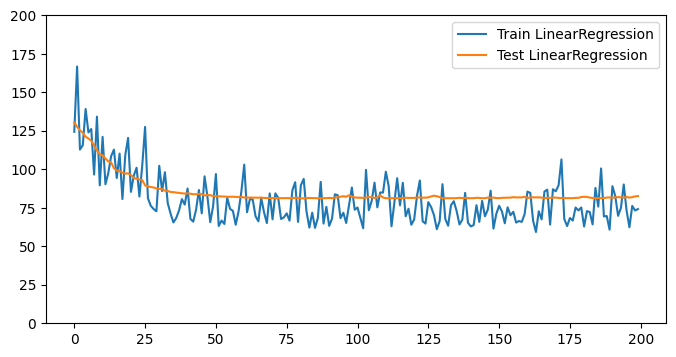

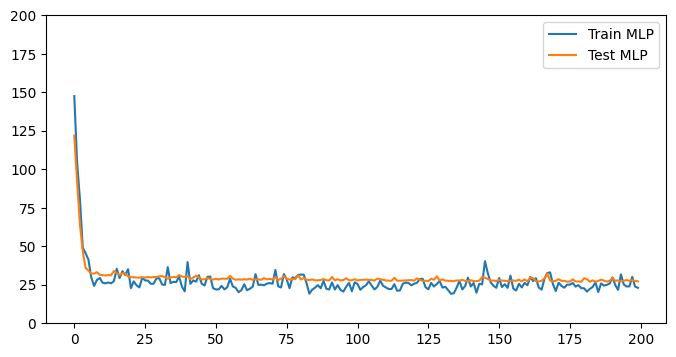

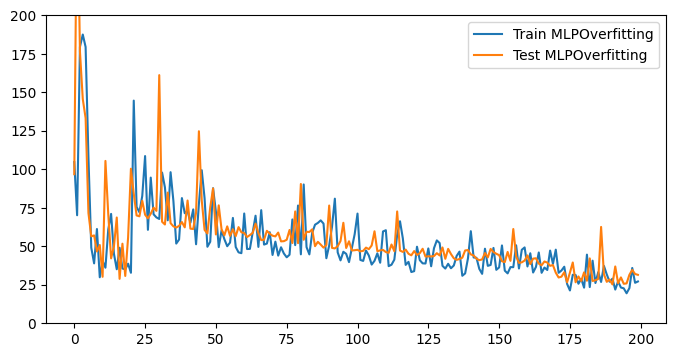

In [16]:
# 绘制每个模型的训练误差和测试误差曲线
for i, model in enumerate(models):
    plt.figure(figsize=(8, 4))  # 为当前模型创建一个新的画布
    plt.plot(range(num_epochs), train_losses[i], label=f"Train {model.__class__.__name__}")  # 绘制训练集 loss 曲线
    plt.plot(range(num_epochs), test_losses[i], label=f"Test {model.__class__.__name__}")    # 绘制测试集 loss 曲线
    plt.legend()
    plt.ylim((0, 200))  # 将纵轴范围限制在 0～200，方便比较不同模型
    plt.show()